# 📊 Reporte Semanal de Competencias
---
**Instrucciones:** 
1. Coloca `QM-CAPS.xlsx` y tu archivo actualizado de data en la **misma carpeta** que este notebook
2. En la celda de abajo, cambia el nombre del archivo `DATA_FILE` si es diferente
3. Corre todas las celdas (Run All)
4. El notebook guarda automáticamente un snapshot para comparar la próxima semana

## ⚙️ Configuración

In [1]:
# CONFIGURACIÓN - Cambia aquí el nombre del archivo
# ═══════════════════════════════════════════════════════

QM_FILE = "QM-CAPS.xlsx"       # Plan fijo (no cambia)
DATA_FILE = "data_new.xlsx"    # ← Cambia este nombre cada semana

## 📥 Carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os, shutil, warnings
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

SNAPSHOT_DIR = "snapshots"
os.makedirs(SNAPSHOT_DIR, exist_ok=True)

# Cargar archivos
qm = pd.read_excel(QM_FILE)
dn = pd.read_excel(DATA_FILE)
qm.columns = qm.columns.str.strip()
dn.columns = dn.columns.str.strip()

MESES = ['Feb','Mar','Abr','May','Jun','Jul','Ago','Sep']

print(f"✅ QM-CAPS cargado: {len(qm)} registros")
print(f"✅ {DATA_FILE} cargado: {len(dn)} registros")

✅ QM-CAPS cargado: 1033 registros
✅ data_new.xlsx cargado: 1011 registros


In [4]:
dn

,Role,Employee,Role.1,Competency,OnTarget,Current,Target
0,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,5S,1,3,3
1,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM Overview,1,2,2
2,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 1,1,3,3
3,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 2,0,2,3
4,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 3,0,2,3
...,...,...,...,...,...,...,...
1006,PT,Ocegueda Omar,MT/ MT Specialists - Phase 1,UPS,1,2,2
1007,PT,Ocegueda Omar,PM Champion - Phase 2,BDE,1,3,3
1008,PT,Ocegueda Omar,PM Champion - Phase 2,DH DMS,0,2,4
1009,PT,Ocegueda Omar,PM Champion - Phase 2,MPS,0,2,3


## 🔗 Cruce de datos

In [5]:
# Renombrar columnas para evitar conflictos
qm_r = qm.rename(columns={'Target': 'Target_QM', 'Current': 'Current_QM'})
dn_r = dn.rename(columns={'Current': 'Current_DN', 'Target': 'Target_DN'})

# Si data_new tiene columna duplicada 'Role', pandas la renombra a 'Role.1'
role_col_dn = 'Role.1' if 'Role.1' in dn_r.columns else 'Role'

# Merge exacto por Employee + Competency + Role
merged_exact = pd.merge(
    qm_r[['Employee','Competency','Current_QM','Target_QM','Role','BU','Cell'] + MESES],
    dn_r[['Employee','Competency','Current_DN','Target_DN','OnTarget',role_col_dn]],
    left_on=['Employee','Competency','Role'],
    right_on=['Employee','Competency',role_col_dn],
    how='inner'
)

# Para los que no matchearon, intentar solo por Employee + Competency
keys_matched = set(zip(merged_exact['Employee'], merged_exact['Competency'], merged_exact['Role']))
qm_remaining = qm_r[~qm_r.apply(lambda r: (r['Employee'], r['Competency'], r['Role']) in keys_matched, axis=1)]

merged_fuzzy = pd.merge(
    qm_remaining[['Employee','Competency','Current_QM','Target_QM','Role','BU','Cell'] + MESES],
    dn_r[['Employee','Competency','Current_DN','Target_DN','OnTarget',role_col_dn]],
    on=['Employee','Competency'],
    how='left',
    indicator=True
)
fuzzy_ok = merged_fuzzy[merged_fuzzy['_merge'] == 'both'].drop(columns=['_merge'])
no_match = merged_fuzzy[merged_fuzzy['_merge'] == 'left_only'].drop(columns=['_merge'])

# Combinar
df = pd.concat([merged_exact, fuzzy_ok], ignore_index=True)

# Calcular métricas
df['Gap_Original'] = df['Target_QM'] - df['Current_QM']
df['Gap_Actual'] = df['Target_QM'] - df['Current_DN']
df['Avance'] = df['Current_DN'] - df['Current_QM']
df['En_Target'] = (df['Current_DN'] >= df['Target_QM']).astype(int)

print(f"✅ {len(df)} competencias cruzadas exitosamente")
print(f"⚠️  {len(no_match)} registros sin coincidencia ({no_match['Employee'].nunique()} empleados)")
if len(no_match) > 0:
    print(f"   → Empleados: {', '.join(no_match['Employee'].unique())}")

✅ 1009 competencias cruzadas exitosamente
⚠️  29 registros sin coincidencia (1 empleados)
   → Empleados: Najera Ivan


## 💾 Snapshot semanal (comparación automática)

In [6]:
# Guardar snapshot de esta semana
today = datetime.now().strftime("%Y-%m-%d")
snapshot_file = os.path.join(SNAPSHOT_DIR, f"snapshot_{today}.csv")
df[['Employee','Competency','Role','Current_DN','Target_QM','En_Target']].to_csv(snapshot_file, index=False)
print(f"💾 Snapshot guardado: {snapshot_file}")

# Buscar snapshot anterior
snapshots = sorted([f for f in os.listdir(SNAPSHOT_DIR) if f.startswith("snapshot_") and f != os.path.basename(snapshot_file)])
hay_anterior = len(snapshots) > 0

if hay_anterior:
    prev_file = os.path.join(SNAPSHOT_DIR, snapshots[-1])
    prev = pd.read_csv(prev_file)
    print(f"📂 Comparando con: {snapshots[-1]}")
    
    comp = pd.merge(
        df[['Employee','Competency','Role','Current_DN','Target_QM','En_Target']],
        prev[['Employee','Competency','Current_DN','En_Target']],
        on=['Employee','Competency'],
        suffixes=('_actual','_anterior'),
        how='left'
    )
    comp['Cambio_Semanal'] = comp['Current_DN_actual'] - comp['Current_DN_anterior'].fillna(comp['Current_DN_actual'])
    comp['Nuevo_En_Target'] = ((comp['En_Target_actual'] == 1) & (comp['En_Target_anterior'] == 0))
    
    avances_semana = comp[comp['Cambio_Semanal'] > 0]
    nuevos_target = comp[comp['Nuevo_En_Target']]
    
    print(f"\n🔼 Avances esta semana: {len(avances_semana)} competencias mejoraron")
    print(f"🎯 Nuevas en target: {len(nuevos_target)} competencias alcanzaron su objetivo")
else:
    print("ℹ️  Primera ejecución — no hay snapshot anterior para comparar.")
    print("   La próxima semana verás los avances automáticamente.")
    avances_semana = pd.DataFrame()
    nuevos_target = pd.DataFrame()

💾 Snapshot guardado: snapshots\snapshot_2026-03-19.csv
ℹ️  Primera ejecución — no hay snapshot anterior para comparar.
   La próxima semana verás los avances automáticamente.


## 📈 Avances de esta semana

In [7]:
if hay_anterior and len(avances_semana) > 0:
    print("═" * 70)
    print("COMPETENCIAS QUE MEJORARON ESTA SEMANA")
    print("═" * 70)
    display(avances_semana[['Employee','Competency','Current_DN_anterior',
                            'Current_DN_actual','Target_QM','Cambio_Semanal']]
            .rename(columns={
                'Current_DN_anterior': 'Semana Pasada',
                'Current_DN_actual': 'Esta Semana', 
                'Target_QM': 'Target',
                'Cambio_Semanal': 'Avance'
            }).sort_values('Employee').reset_index(drop=True))
    
    # Resumen por empleado
    resumen_avance = avances_semana.groupby('Employee').agg(
        Competencias_Mejoradas=('Competency','count'),
        Puntos_Avanzados=('Cambio_Semanal','sum')
    ).sort_values('Puntos_Avanzados', ascending=False)
    
    print("\n🏆 Ranking de avance semanal:")
    display(resumen_avance)
elif hay_anterior:
    print("ℹ️  No se detectaron avances esta semana.")
else:
    print("ℹ️  Primera ejecución — la comparación semanal estará disponible la próxima vez.")

ℹ️  Primera ejecución — la comparación semanal estará disponible la próxima vez.


In [8]:
if hay_anterior and len(nuevos_target) > 0:
    print("═" * 70)
    print("🎯 COMPETENCIAS QUE ALCANZARON EL TARGET ESTA SEMANA")
    print("═" * 70)
    display(nuevos_target[['Employee','Competency','Current_DN_anterior',
                           'Current_DN_actual','Target_QM']]
            .rename(columns={
                'Current_DN_anterior': 'Semana Pasada',
                'Current_DN_actual': 'Esta Semana',
                'Target_QM': 'Target'
            }).sort_values('Employee').reset_index(drop=True))
elif hay_anterior:
    print("ℹ️  Ninguna competencia nueva alcanzó el target esta semana.")

## 📋 Resumen General

In [9]:
total = len(df)
en_target = df['En_Target'].sum()
pendientes = total - en_target
pct = en_target / total * 100

print("═" * 50)
print(f"  Total competencias evaluadas:  {total}")
print(f"  Ya en target:                  {en_target}  ({pct:.1f}%)")
print(f"  Pendientes:                    {pendientes}  ({100-pct:.1f}%)")
print(f"  Empleados evaluados:           {df['Employee'].nunique()}")
print("═" * 50)

# Tabla resumen por empleado
emp = df.groupby('Employee').agg(
    Total=('Competency','count'),
    En_Target=('En_Target','sum'),
    Gap_Actual=('Gap_Actual','sum'),
    Avance_vs_Original=('Avance','sum')
).reset_index()
emp['Pendientes'] = emp['Total'] - emp['En_Target']
emp['%_En_Target'] = (emp['En_Target'] / emp['Total'] * 100).round(1)
emp = emp.sort_values('Gap_Actual', ascending=False)

print("\n📊 Resumen por empleado (ordenado por gap pendiente):\n")
display(emp[['Employee','Total','En_Target','Pendientes','%_En_Target','Gap_Actual','Avance_vs_Original']]
        .reset_index(drop=True))

══════════════════════════════════════════════════
  Total competencias evaluadas:  1009
  Ya en target:                  573  (56.8%)
  Pendientes:                    436  (43.2%)
  Empleados evaluados:           26
══════════════════════════════════════════════════

📊 Resumen por empleado (ordenado por gap pendiente):



,Employee,Total,En_Target,Pendientes,%_En_Target,Gap_Actual,Avance_vs_Original
0,Barajas Omar,56,10,46,17.9,58.0,0.0
1,Pellegrini Oscar,40,9,31,22.5,49.0,0.0
2,Olvera Bernardette,76,40,36,52.6,47.0,2.0
3,Ocegueda Omar,65,29,36,44.6,40.0,2.0
4,Landin Atxel,29,4,25,13.8,35.0,0.0
5,Mejia Leonardo,29,5,24,17.2,28.0,1.0
6,Flores Silvia,36,18,18,50.0,23.0,0.0
7,Farias Villalvazo Julio Cesar,56,35,21,62.5,21.0,0.0
8,Baltazar Andres,38,19,19,50.0,21.0,0.0
9,Solorzano Nicolas,36,19,17,52.8,19.0,0.0


## 📊 Visualizaciones

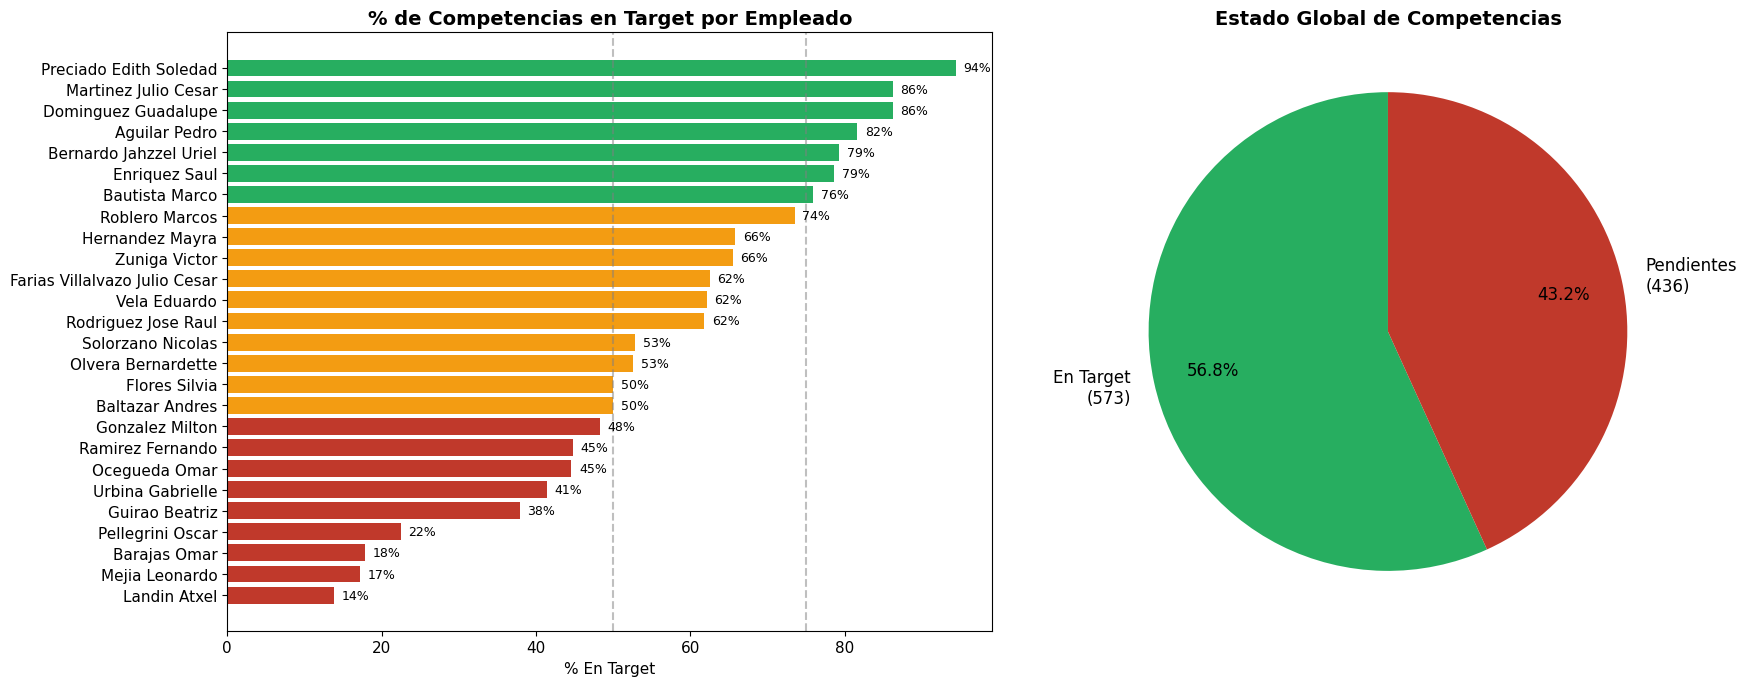

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1) % en target por empleado
emp_plot = emp.sort_values('%_En_Target', ascending=True)
colors = ['#c0392b' if v < 50 else '#f39c12' if v < 75 else '#27ae60' for v in emp_plot['%_En_Target']]
axes[0].barh(emp_plot['Employee'], emp_plot['%_En_Target'], color=colors)
axes[0].set_xlabel('% En Target')
axes[0].set_title('% de Competencias en Target por Empleado')
axes[0].axvline(x=50, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=75, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(emp_plot['%_En_Target']):
    axes[0].text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)

# 2) Pie global
en_t = df['En_Target'].sum()
pend = len(df) - en_t
axes[1].pie([en_t, pend], labels=[f'En Target\n({en_t})', f'Pendientes\n({pend})'],
            colors=['#27ae60','#c0392b'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12}, pctdistance=0.75)
axes[1].set_title('Estado Global de Competencias')

plt.tight_layout()
plt.show()

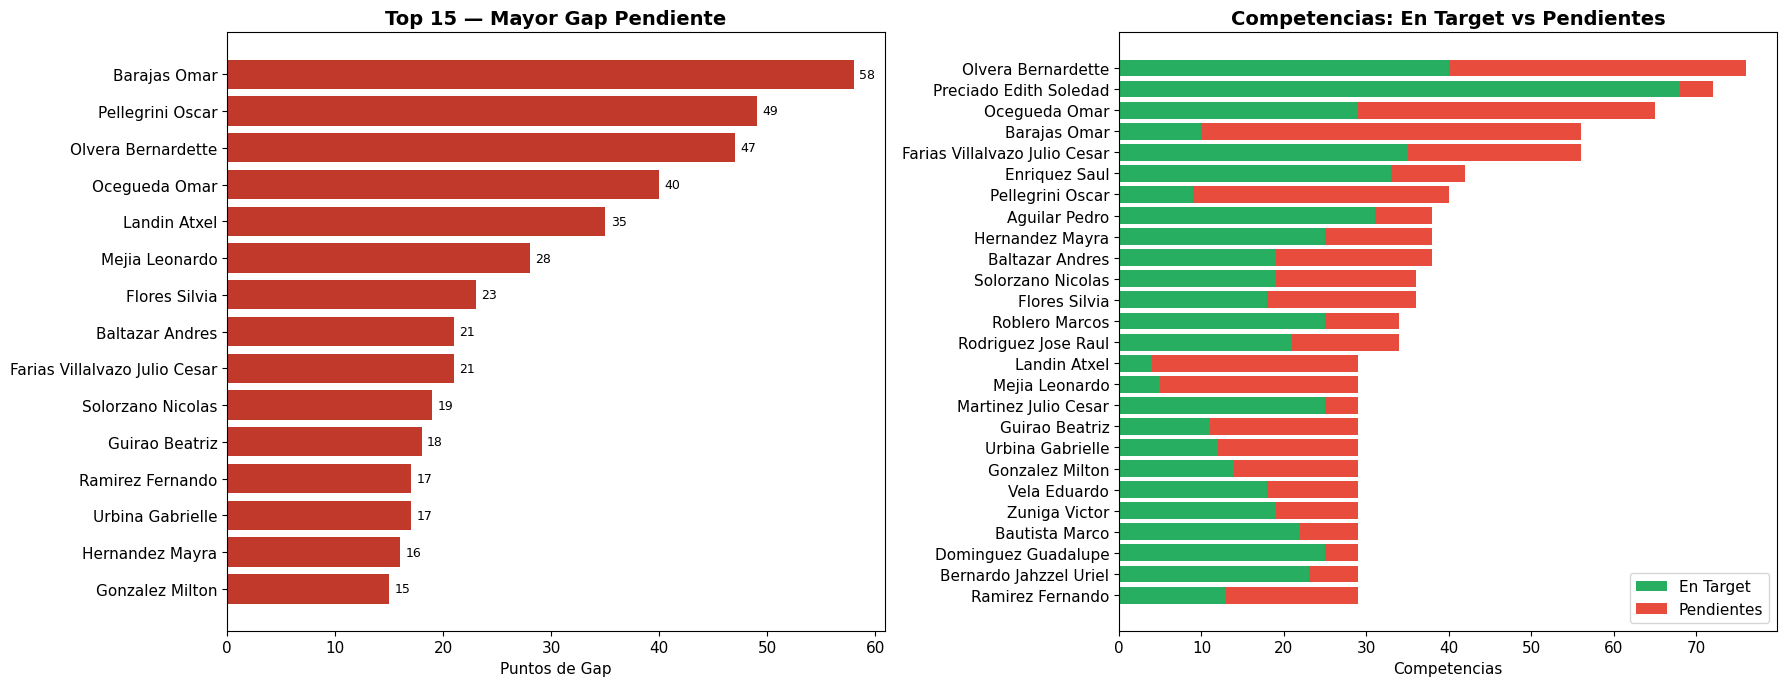

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 3) Gap actual por empleado (top 15)
emp_gap = emp.nlargest(15, 'Gap_Actual').sort_values('Gap_Actual', ascending=True)
axes[0].barh(emp_gap['Employee'], emp_gap['Gap_Actual'], color='#c0392b')
axes[0].set_xlabel('Puntos de Gap')
axes[0].set_title('Top 15 — Mayor Gap Pendiente')
for i, v in enumerate(emp_gap['Gap_Actual']):
    axes[0].text(v + 0.5, i, str(int(v)), va='center', fontsize=9)

# 4) Competencias en target vs pendientes (stacked)
emp_stack = emp.sort_values('Total', ascending=True)
axes[1].barh(emp_stack['Employee'], emp_stack['En_Target'], color='#27ae60', label='En Target')
axes[1].barh(emp_stack['Employee'], emp_stack['Pendientes'], left=emp_stack['En_Target'], color='#e74c3c', label='Pendientes')
axes[1].set_xlabel('Competencias')
axes[1].set_title('Competencias: En Target vs Pendientes')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 📅 Cambios Pendientes Programados

Tabla con los próximos cambios programados que **aún no se han completado** (donde el Current actual es menor al valor programado).

In [12]:
cambios = []
for _, r in df.iterrows():
    vals = [r[m] for m in MESES]
    for i in range(1, len(vals)):
        prev, cur = vals[i-1], vals[i]
        if pd.notna(prev) and pd.notna(cur) and cur != prev:
            if pd.notna(r['Current_DN']) and r['Current_DN'] < cur:
                cambios.append({
                    'Change_Type': f"{int(prev)}→{int(cur)}",
                    'Employee': r['Employee'],
                    'Month': MESES[i],
                    'Competency': r['Competency']
                })

cambios_df = pd.DataFrame(cambios, columns=['Change_Type','Employee','Month','Competency'])
mes_ord = {m: i for i, m in enumerate(MESES)}
cambios_df['_ord'] = cambios_df['Month'].map(mes_ord)
cambios_df = cambios_df.sort_values(['Employee','_ord','Competency']).drop(columns='_ord').reset_index(drop=True)

print(f"Total cambios pendientes: {len(cambios_df)}")
print(f"Empleados con cambios: {cambios_df['Employee'].nunique()}")
print(f"\nDistribución por mes:")
for m in MESES:
    n = (cambios_df['Month'] == m).sum()
    if n > 0:
        print(f"  {m}: {n} cambios")

display(cambios_df)

Total cambios pendientes: 271
Empleados con cambios: 26

Distribución por mes:
  Mar: 73 cambios
  Abr: 66 cambios
  May: 65 cambios
  Jun: 44 cambios
  Jul: 20 cambios
  Ago: 3 cambios


,Change_Type,Employee,Month,Competency
0,2→3,Aguilar Pedro,Mar,QRP
1,2→3,Aguilar Pedro,Abr,Safety Map
2,2→3,Aguilar Pedro,May,Safety Trigger
3,2→3,Baltazar Andres,Mar,5S
4,2→3,Baltazar Andres,Mar,CL DMS
...,...,...,...,...
266,2→3,Vela Eduardo,Jun,FPQ
267,1→2,Zuniga Victor,Mar,Q BOS
268,2→3,Zuniga Victor,Abr,IPS
269,2→3,Zuniga Victor,May,Q BOS


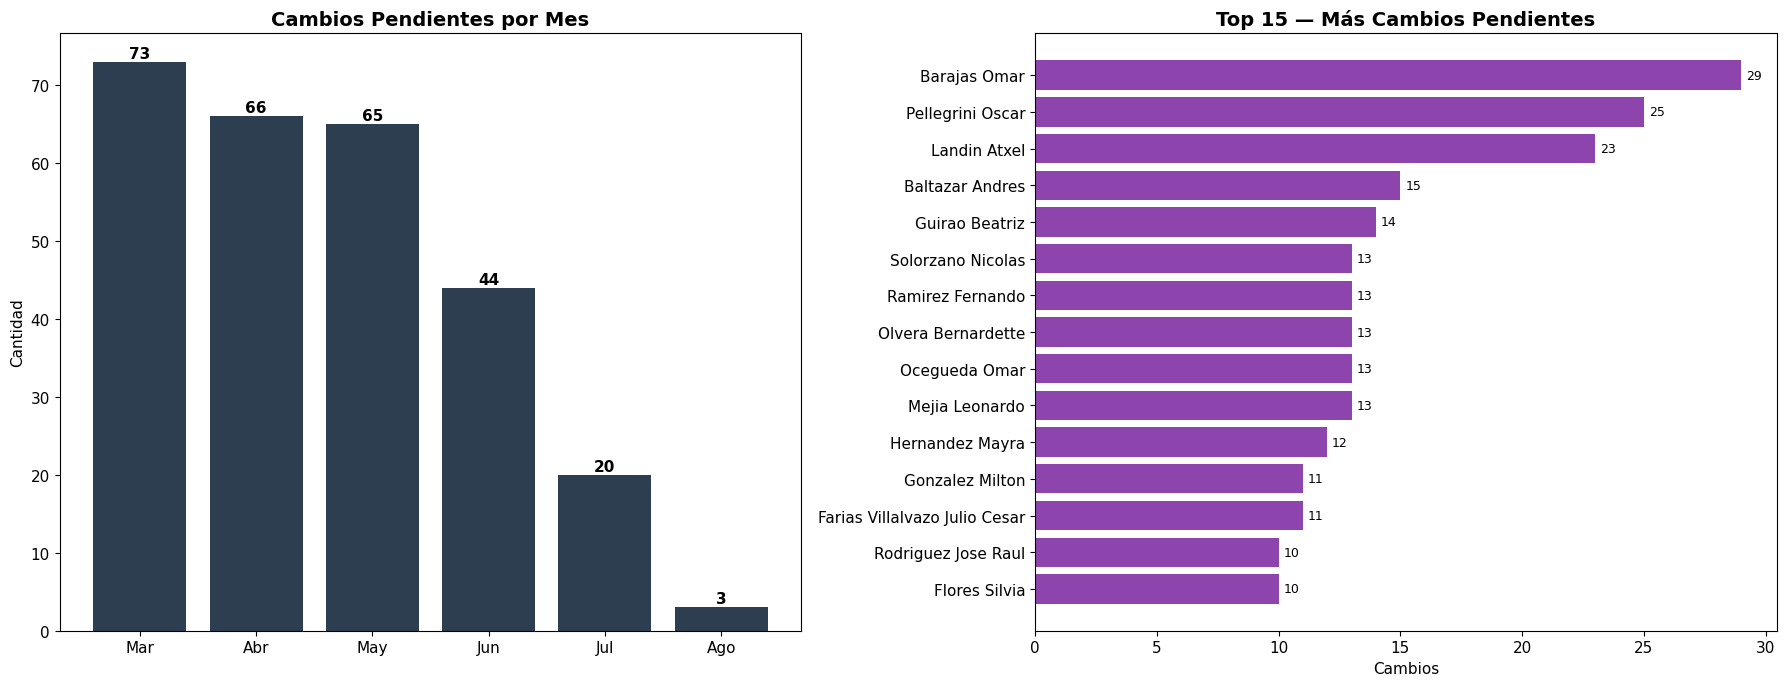

In [13]:
# Visualización: cambios pendientes por mes y empleado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Por mes
por_mes = cambios_df.groupby('Month').size().reindex([m for m in MESES if m in cambios_df['Month'].values])
axes[0].bar(por_mes.index, por_mes.values, color='#2c3e50')
axes[0].set_title('Cambios Pendientes por Mes')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(por_mes.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Por empleado (top 15)
por_emp = cambios_df.groupby('Employee').size().nlargest(15).sort_values(ascending=True)
axes[1].barh(por_emp.index, por_emp.values, color='#8e44ad')
axes[1].set_title('Top 15 — Más Cambios Pendientes')
axes[1].set_xlabel('Cambios')
for i, v in enumerate(por_emp.values):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## ⚠️ Registros sin coincidencia

In [14]:
if len(no_match) > 0:
    print(f"Los siguientes {len(no_match)} registros de QM-CAPS no tienen coincidencia en {DATA_FILE}:\n")
    display(no_match[['Employee','Competency','Role','Current_QM','Target_QM']].reset_index(drop=True))
else:
    print("✅ Todos los registros coinciden entre ambos archivos.")

Los siguientes 29 registros de QM-CAPS no tienen coincidencia en data_new.xlsx:



,Employee,Competency,Role,Current_QM,Target_QM
0,Najera Ivan,5S,Equipment Owner Secondary - Phase 1,1,3
1,Najera Ivan,AM Overview,Equipment Owner Secondary - Phase 1,1,2
2,Najera Ivan,AM step 1,Equipment Owner Secondary - Phase 1,1,3
3,Najera Ivan,AM step 2,Equipment Owner Secondary - Phase 1,1,3
4,Najera Ivan,AM step 3,Equipment Owner Secondary - Phase 1,1,3
5,Najera Ivan,BDE,Equipment Owner Secondary - Phase 1,1,3
6,Najera Ivan,CIL DMS,Equipment Owner Secondary - Phase 1,1,3
7,Najera Ivan,CL DMS,Equipment Owner Secondary - Phase 1,1,3
8,Najera Ivan,CO DMS,Equipment Owner Secondary - Phase 1,1,2
9,Najera Ivan,Daily Direction Setting (DDS),Equipment Owner Secondary - Phase 1,1,2


---
## ✅ Fin del reporte

**Próximos pasos:**
- La próxima semana, actualiza `DATA_FILE` con el nuevo archivo y corre el notebook de nuevo
- Los avances semanales se mostrarán automáticamente comparando con el snapshot anterior
- Los snapshots se guardan en la carpeta `snapshots/`